In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time

from glob import glob

import plotly.express as px
import numpy as np
import seaborn as sns
from datetime import datetime
import pytz

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

! pip install xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

color_pal = sns.color_palette()
import requests
import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Assemble a list of path names that match a pattern in glob
ger_files = glob("Germany_ENTSO-E_*.csv")
ger_files

['Germany_ENTSO-E_2015.csv',
 'Germany_ENTSO-E_2016.csv',
 'Germany_ENTSO-E_2017.csv',
 'Germany_ENTSO-E_2018.csv',
 'Germany_ENTSO-E_2019.csv',
 'Germany_ENTSO-E_2020.csv',
 'Germany_ENTSO-E_2021.csv',
 'Germany_ENTSO-E_2022.csv',
 'Germany_ENTSO-E_2023.csv',
 'Germany_ENTSO-E_2024.csv',
 'Germany_ENTSO-E_2025.csv']

In [3]:
# Read all files into a list of DataFrames
germany_df_list = [pd.read_csv(file) for file in ger_files]

# Concatenate into one DataFrame
germany_entso_df = pd.concat(germany_df_list, ignore_index=True)

# Inspect a DataFrame using the info and shape 
germany_entso_df.info()
germany_entso_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366076 entries, 0 to 366075
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Timestamp  366076 non-null  object 
 1   Germany    366032 non-null  float64
dtypes: float64(1), object(1)
memory usage: 5.6+ MB


(366076, 2)

In [4]:
# Rename column
germany_entso_df.rename(columns={"Germany": "electricity_load_MW"}, inplace=True)

In [5]:
# Print only the top 5 row
germany_entso_df.head()

,Timestamp,electricity_load_MW
0,2015-01-01T00:00:00,45274.0
1,2015-01-01T00:15:00,44870.0
2,2015-01-01T00:30:00,44964.0
3,2015-01-01T00:45:00,44894.0
4,2015-01-01T01:00:00,44442.0


In [6]:
# Convert to naïve datetime
germany_entso_df["Timestamp"] = pd.to_datetime(germany_entso_df["Timestamp"])

# Localize to Europe/Berlin, handling DST gaps
germany_entso_df["Timestamp"] = germany_entso_df["Timestamp"].dt.tz_localize(
 'Europe/Berlin', nonexistent='shift_forward', ambiguous=True
)
# Set as index
germany_entso_df = germany_entso_df.set_index("Timestamp")
germany_entso_df

,electricity_load_MW
Timestamp,
2015-01-01 00:00:00+01:00,45274.0
2015-01-01 00:15:00+01:00,44870.0
2015-01-01 00:30:00+01:00,44964.0
2015-01-01 00:45:00+01:00,44894.0
2015-01-01 01:00:00+01:00,44442.0
...,...
2025-06-09 19:45:00+02:00,44272.0
2025-06-09 20:00:00+02:00,44751.0
2025-06-09 20:15:00+02:00,44367.0


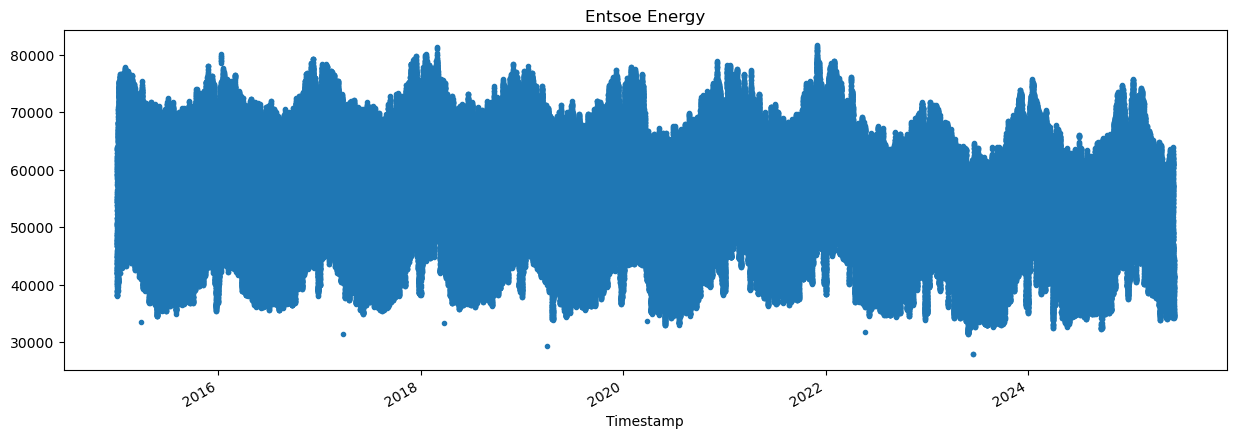

In [7]:
# Plot Electricity Load over Time before resmaple
germany_entso_df["electricity_load_MW"].plot(style=".", figsize=(15, 5), label = "color", title="Entsoe Energy");

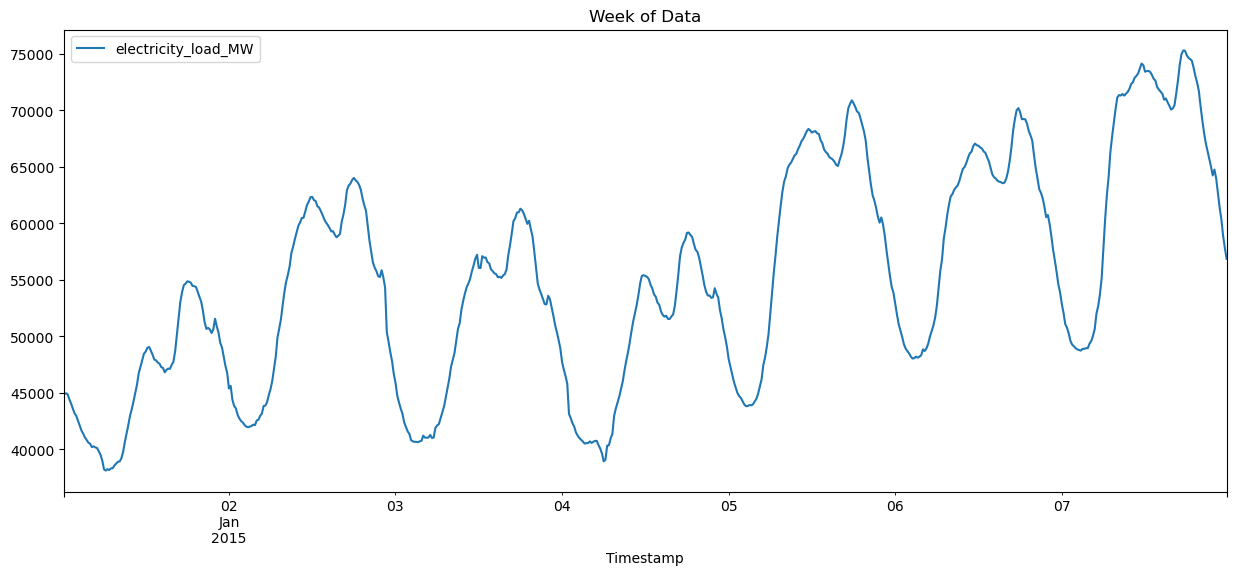

In [8]:
# Visualize Electricity Load (1 Week) over Time before resmaple
germany_entso_df["electricity_load_MW"].loc[(germany_entso_df.index > "2015-01-01") & (germany_entso_df.index < "2015-01-08")].plot(figsize=(15, 6), title="Week of Data")
plt.legend()
plt.show();

In [9]:
# Check the missing value
germany_entso_df.isnull().sum()

electricity_load_MW    44
dtype: int64

In [10]:
# Fill the missing value with Interpolation method
germany_entso_df["electricity_load_MW"] = germany_entso_df["electricity_load_MW"].interpolate(method="time")
germany_entso_df.head()

,electricity_load_MW
Timestamp,
2015-01-01 00:00:00+01:00,45274.0
2015-01-01 00:15:00+01:00,44870.0
2015-01-01 00:30:00+01:00,44964.0
2015-01-01 00:45:00+01:00,44894.0
2015-01-01 01:00:00+01:00,44442.0


In [11]:
# Resample
germany_entso_df = germany_entso_df["electricity_load_MW"].resample("1h").mean().to_frame()
germany_entso_df.head()

,electricity_load_MW
Timestamp,
2015-01-01 00:00:00+01:00,45000.50
2015-01-01 01:00:00+01:00,43833.25
2015-01-01 02:00:00+01:00,42322.25
2015-01-01 03:00:00+01:00,40966.00
2015-01-01 04:00:00+01:00,40283.50


In [12]:
# Check the missing value after Resample
germany_entso_df.isnull().sum()

electricity_load_MW    10
dtype: int64

In [13]:
# Fill the missing value after Resample with Interpolation method
germany_entso_df["electricity_load_MW"] = germany_entso_df["electricity_load_MW"].interpolate()
germany_entso_df.head()

,electricity_load_MW
Timestamp,
2015-01-01 00:00:00+01:00,45000.50
2015-01-01 01:00:00+01:00,43833.25
2015-01-01 02:00:00+01:00,42322.25
2015-01-01 03:00:00+01:00,40966.00
2015-01-01 04:00:00+01:00,40283.50


In [14]:
# Check the missing value
germany_entso_df.isnull().sum()

electricity_load_MW    0
dtype: int64

In [15]:
# Display the shape
germany_entso_df.shape

(91508, 1)

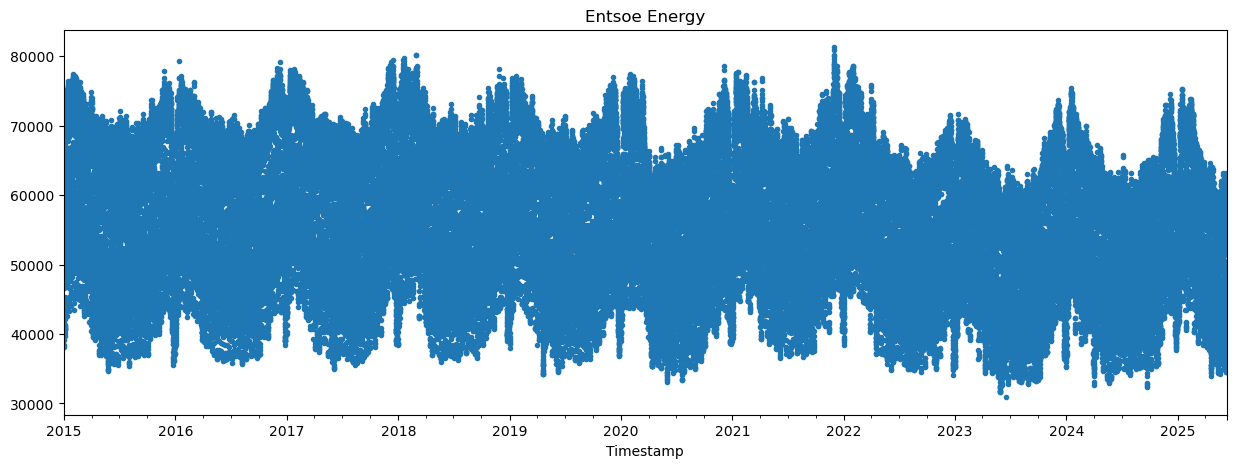

In [16]:
# Plot Electricity Load/Demand over Time after Resample
germany_entso_df["electricity_load_MW"].plot(style=".", figsize=(15, 5), label = "color", title="Entsoe Energy");
# No necssary to perform this analysis because plt.show()

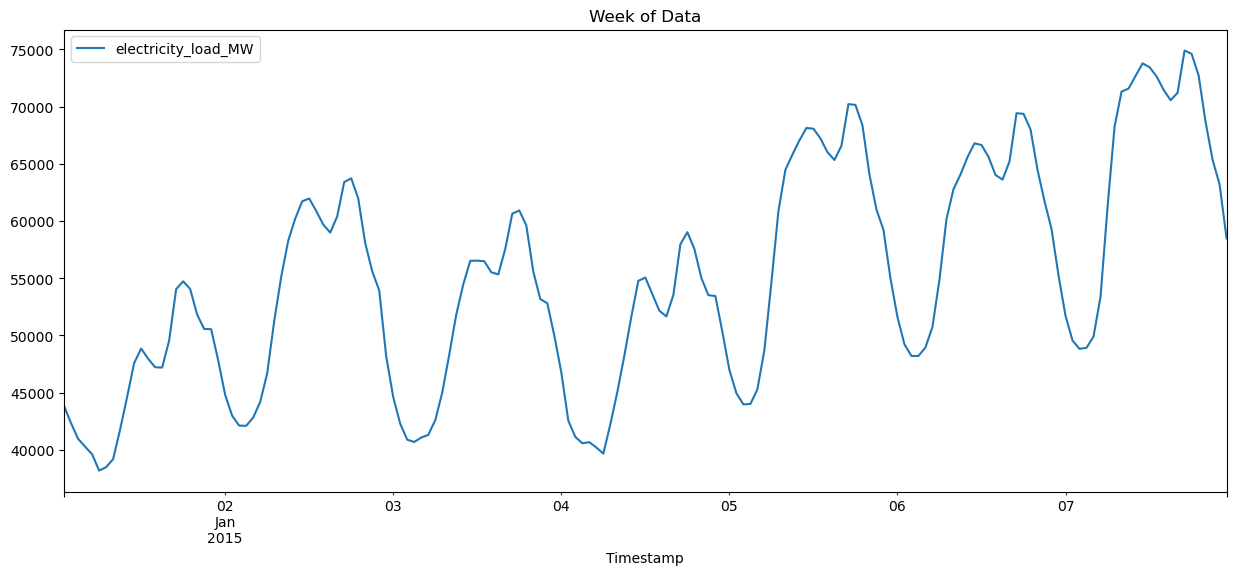

In [17]:
# Plot Electricity Load (in one week) over Time after Resample
germany_entso_df["electricity_load_MW"].loc[(germany_entso_df.index > "2015-01-01") & (germany_entso_df.index < "2015-01-08")].plot(figsize=(15, 6), title="Week of Data")
plt.legend()
plt.show();

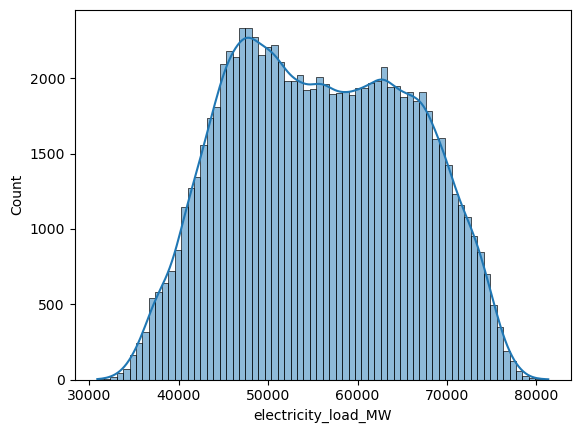

In [18]:
# Plot Histogram
sns.histplot(germany_entso_df["electricity_load_MW"], kde=True);

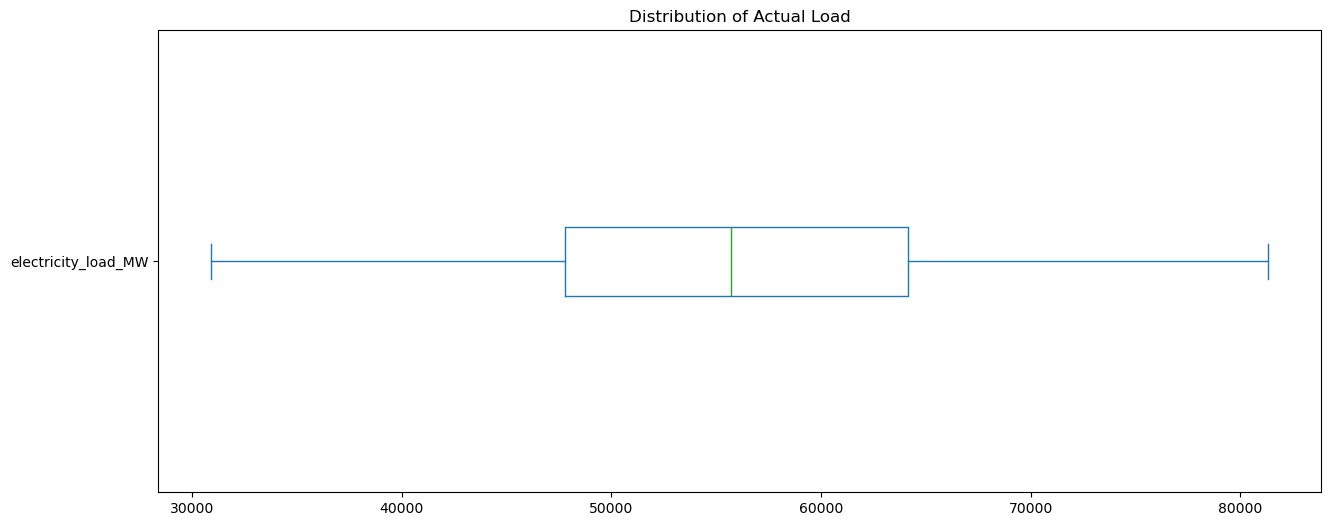

In [19]:
# Create a boxplot
fig, ax = plt.subplots(figsize=(15, 6))
germany_entso_df["electricity_load_MW"].plot(kind="box", vert=False, title="Distribution of Actual Load", ax=ax);

In [20]:
# Descriptive Statistics
germany_entso_df["electricity_load_MW"].describe().round(2)

count    91508.00
mean     55968.40
std       9971.47
min      30902.75
25%      47785.69
50%      55691.12
75%      64129.81
max      81319.50
Name: electricity_load_MW, dtype: float64

# Feature Engineering

In [21]:
# Create Date-Time Features
germany_entso_df["hour"] = germany_entso_df.index.hour
germany_entso_df["dayofweek"] = germany_entso_df.index.dayofweek
germany_entso_df['is_weekend'] = germany_entso_df["dayofweek"].isin([5,6]).astype(int)
germany_entso_df["quarter"] = germany_entso_df.index.quarter
germany_entso_df["month"] = germany_entso_df.index.month
germany_entso_df["year"] = germany_entso_df.index.year
germany_entso_df["dayofyear"] = germany_entso_df.index.dayofyear
germany_entso_df.head()

,electricity_load_MW,hour,dayofweek,is_weekend,quarter,month,year,dayofyear
Timestamp,,,,,,,,
2015-01-01 00:00:00+01:00,45000.50,0,3,0,1,1,2015,1
2015-01-01 01:00:00+01:00,43833.25,1,3,0,1,1,2015,1
2015-01-01 02:00:00+01:00,42322.25,2,3,0,1,1,2015,1
2015-01-01 03:00:00+01:00,40966.00,3,3,0,1,1,2015,1
2015-01-01 04:00:00+01:00,40283.50,4,3,0,1,1,2015,1


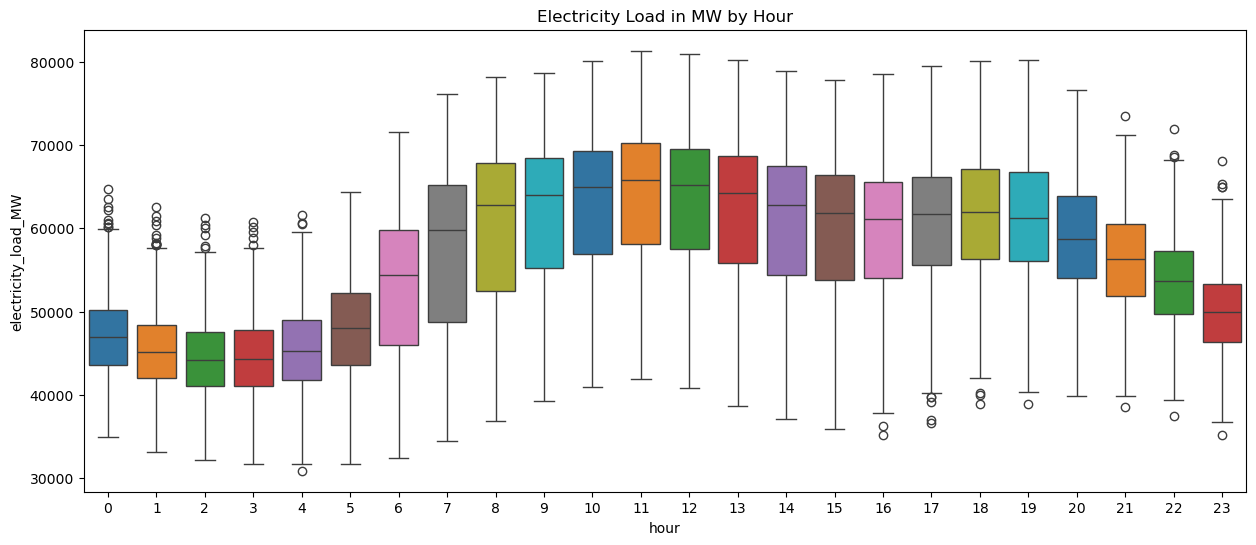

In [22]:
# Boxplot to visualize distribution of electricity Load across different Hours
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(data=germany_entso_df, x="hour", y="electricity_load_MW", hue="hour", palette="tab10", legend=False)
ax.set_title("Electricity Load in MW by Hour");

Text(0.5, 1.0, 'Electricity Load in MW by Month')

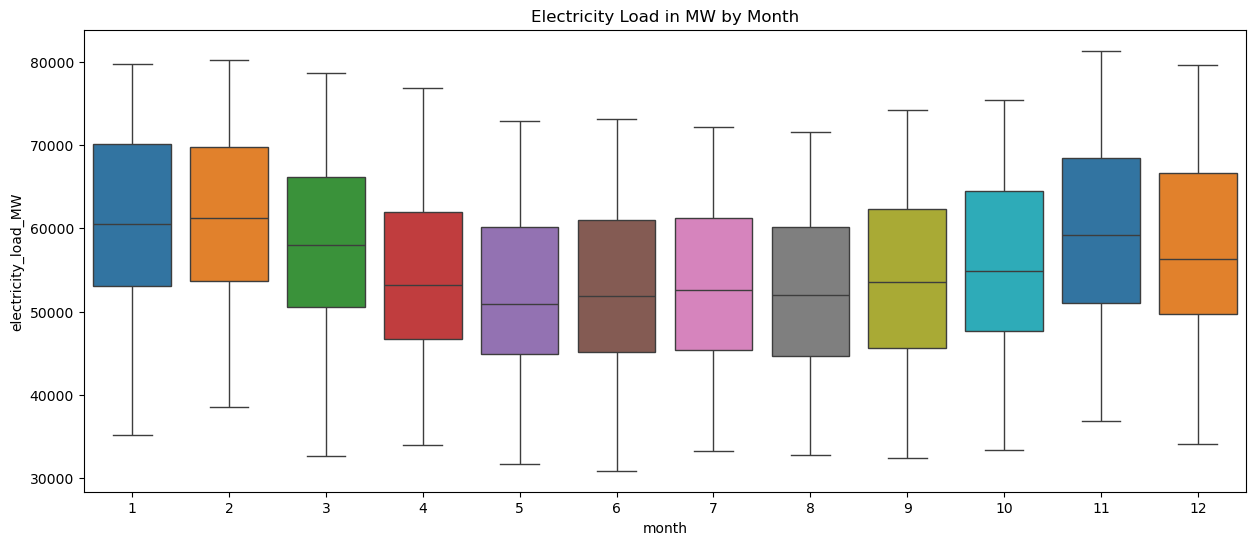

In [23]:
# Boxplot to visualize distribution of electricity Load across different months
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(data=germany_entso_df, x="month", y="electricity_load_MW",  hue="month", palette="tab10", legend=False)
ax.set_title("Electricity Load in MW by Month")
# Looking at the graph, we can see that MW uses by the month terms to peak two times in the Winter season than the fall and spring seasons has a lower than another peak in the middle of summer when everyone running their AC units.

In [24]:
# Lag Features
germany_entso_df["electricity_load_lag_1"] = germany_entso_df["electricity_load_MW"].shift(1)
germany_entso_df["electricity_load_lag_24"] = germany_entso_df["electricity_load_MW"].shift(24)
germany_entso_df["electricity_load_lag_48"] = germany_entso_df["electricity_load_MW"].shift(48)
germany_entso_df["electricity_load_lag_168"] = germany_entso_df["electricity_load_MW"].shift(168) 
germany_entso_df["electricity_load_lag_720"] = germany_entso_df["electricity_load_MW"].shift(720)

# Rolling Statistics
germany_entso_df["electricity_load_rolling_24_mean"] = germany_entso_df["electricity_load_MW"].shift(1).rolling(24).mean()
germany_entso_df["electricity_load_rolling_std_24"] = germany_entso_df["electricity_load_MW"].shift(1).rolling(24).std()
germany_entso_df["electricity_load_rolling_168_mean"] = germany_entso_df["electricity_load_MW"].shift(1).rolling(168).mean()

germany_entso_df.head()

,electricity_load_MW,hour,dayofweek,is_weekend,quarter,month,year,dayofyear,electricity_load_lag_1,electricity_load_lag_24,electricity_load_lag_48,electricity_load_lag_168,electricity_load_lag_720,electricity_load_rolling_24_mean,electricity_load_rolling_std_24,electricity_load_rolling_168_mean
Timestamp,,,,,,,,,,,,,,,,
2015-01-01 00:00:00+01:00,45000.50,0,3,0,1,1,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 01:00:00+01:00,43833.25,1,3,0,1,1,2015,1,45000.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 02:00:00+01:00,42322.25,2,3,0,1,1,2015,1,43833.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 03:00:00+01:00,40966.00,3,3,0,1,1,2015,1,42322.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 04:00:00+01:00,40283.50,4,3,0,1,1,2015,1,40966.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# Drop rows with NaN values
germany_entso_df = germany_entso_df.dropna()  
germany_entso_df = germany_entso_df.sort_index()
germany_entso_df

,electricity_load_MW,hour,dayofweek,is_weekend,quarter,month,year,dayofyear,electricity_load_lag_1,electricity_load_lag_24,electricity_load_lag_48,electricity_load_lag_168,electricity_load_lag_720,electricity_load_rolling_24_mean,electricity_load_rolling_std_24,electricity_load_rolling_168_mean
Timestamp,,,,,,,,,,,,,,,,
2015-01-31 00:00:00+01:00,54393.00,0,5,1,1,1,2015,31,58376.50,54632.00,54432.25,55461.75,45000.50,65557.572917,8317.166539,63586.467262
2015-01-31 01:00:00+01:00,51980.25,1,5,1,1,1,2015,31,54393.00,52414.50,52259.75,53024.75,43833.25,65547.614583,8330.948397,63580.105655
2015-01-31 02:00:00+01:00,50705.50,2,5,1,1,1,2015,31,51980.25,51878.25,50696.00,53935.50,42322.25,65529.520833,8361.128885,63573.888393
2015-01-31 03:00:00+01:00,50054.25,3,5,1,1,1,2015,31,50705.50,52119.75,51249.50,54274.00,40966.00,65480.656250,8447.361424,63554.662202
2015-01-31 04:00:00+01:00,49981.00,4,5,1,1,1,2015,31,50054.25,53252.00,52557.50,54233.50,40283.50,65394.593750,8598.570350,63529.544643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-09 16:00:00+02:00,39745.00,16,0,0,2,6,2025,160,38835.00,40581.75,45767.50,56940.50,41052.00,39644.552083,3207.425773,48815.668155
2025-06-09 17:00:00+02:00,41381.50,17,0,0,2,6,2025,160,39745.00,42501.25,46002.75,57426.25,42602.00,39609.687500,3201.337485,48713.313988
2025-06-09 18:00:00+02:00,43501.00,18,0,0,2,6,2025,160,41381.50,44028.75,46597.00,57160.25,45111.50,39563.031250,3165.320654,48617.809524


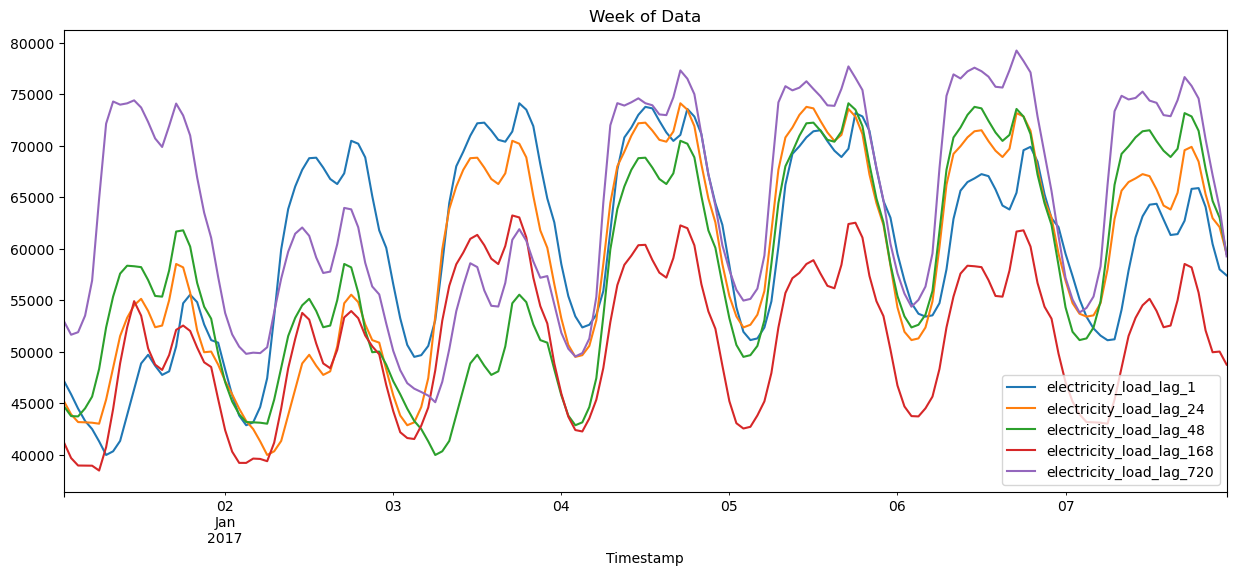

In [26]:
# Visualize all lag features (1 Week) over Time 
germany_entso_df[["electricity_load_lag_1", 
                  "electricity_load_lag_24", 
                  "electricity_load_lag_48", 
                  "electricity_load_lag_168", 
                  "electricity_load_lag_720"
                 ]].loc[(germany_entso_df.index > "2017-01-01") & (germany_entso_df.index < "2017-01-08")].plot(figsize=(15, 6), title="Week of Data")
plt.legend()
plt.show();

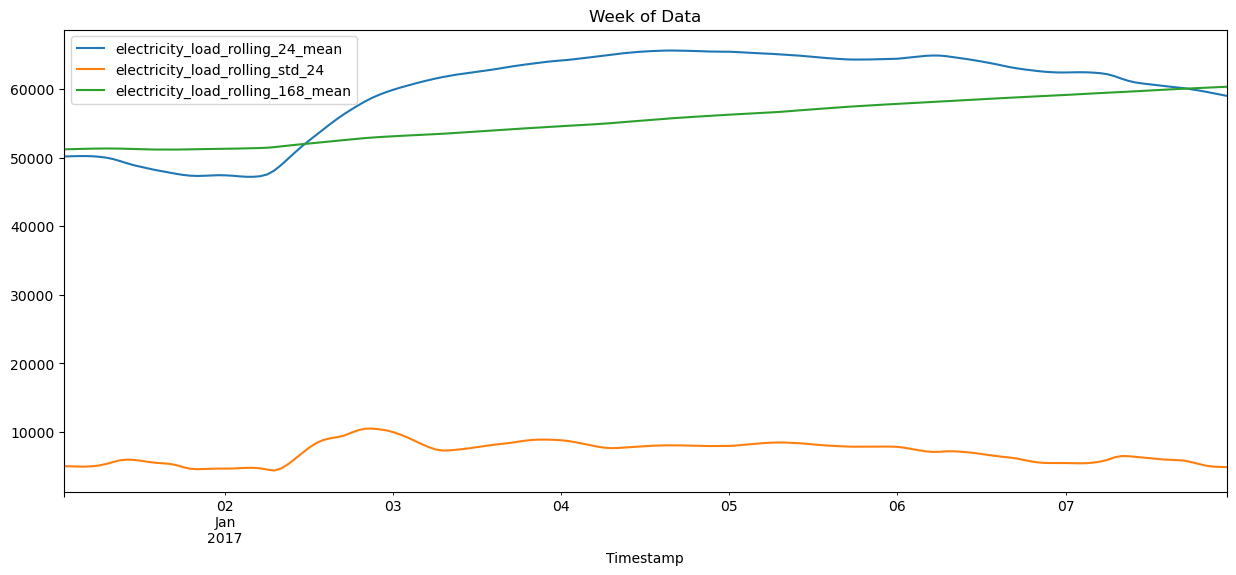

In [27]:
# Visualize all rolling statistics (1 Week) over Time 
germany_entso_df[["electricity_load_rolling_24_mean", 
                  "electricity_load_rolling_std_24", 
                  "electricity_load_rolling_168_mean"
                 ]].loc[(germany_entso_df.index > "2017-01-01") & (germany_entso_df.index < "2017-01-08")].plot(figsize=(15, 6), title="Week of Data")
plt.legend()
plt.show();

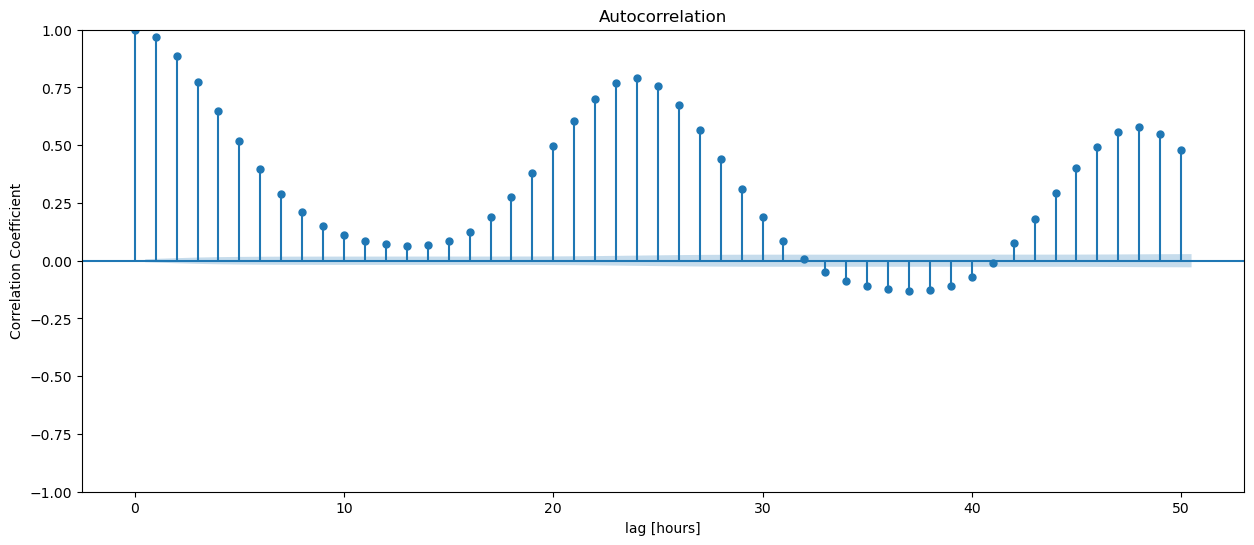

In [28]:
# Create an Autocorrelation Fuction (ACF) plot
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(germany_entso_df["electricity_load_MW"], ax=ax)
plt.xlabel("lag [hours]")
plt.ylabel("Correlation Coefficient");

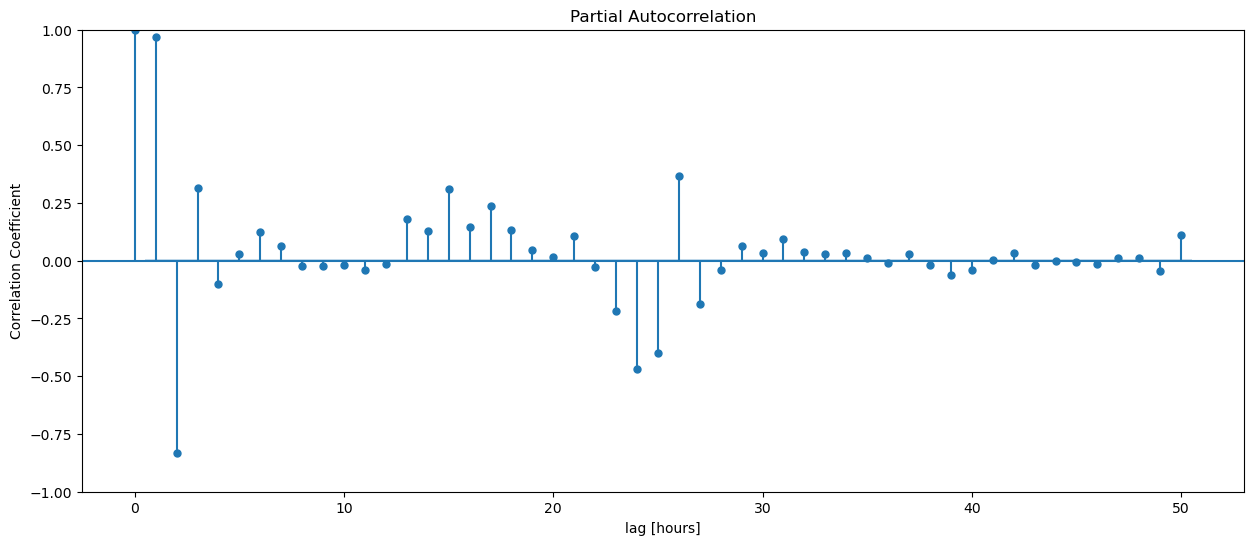

In [29]:
# Create an Partial Autocorrelation Function (PACF) plot
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(germany_entso_df["electricity_load_MW"], ax=ax)
plt.xlabel("lag [hours]")
plt.ylabel("Correlation Coefficient");

In [30]:
# Check full correlation matrix numbers
germany_entso_df.corr()

,electricity_load_MW,hour,dayofweek,is_weekend,quarter,month,year,dayofyear,electricity_load_lag_1,electricity_load_lag_24,electricity_load_lag_48,electricity_load_lag_168,electricity_load_lag_720,electricity_load_rolling_24_mean,electricity_load_rolling_std_24,electricity_load_rolling_168_mean
electricity_load_MW,1.000000,0.367029,-0.368610,-0.458353,-0.084357,-0.084506,-0.158002,-0.084830,0.968846,0.789088,0.578912,0.916302,0.489651,0.603670,0.424919,0.428835
hour,0.367029,1.000000,0.000098,0.000056,-0.000405,-0.000317,-0.000061,-0.000312,0.453390,0.367009,0.366925,0.366317,0.364633,-0.000224,0.032772,-0.000163
dayofweek,-0.368610,0.000098,1.000000,0.790724,0.001753,0.002121,-0.000098,0.001956,-0.361692,0.081644,0.356140,-0.369058,0.355724,-0.201489,-0.268558,0.000032
is_weekend,-0.458353,0.000056,0.790724,1.000000,0.001546,0.000943,-0.000332,0.000880,-0.453844,-0.102957,0.175933,-0.458471,0.175386,-0.418983,-0.370853,0.000378
quarter,-0.084357,-0.000405,0.001753,0.001546,1.000000,0.971377,-0.087913,0.968275,-0.084275,-0.080259,-0.078043,-0.059599,-0.146514,-0.123320,0.116514,-0.163432
month,-0.084506,-0.000317,0.002121,0.000943,0.971377,1.000000,-0.092064,0.996470,-0.084375,-0.078624,-0.075109,-0.046881,-0.131993,-0.122116,0.114728,-0.151593
year,-0.158002,-0.000061,-0.000098,-0.000332,-0.087913,-0.092064,1.000000,-0.091848,-0.158023,-0.158369,-0.158564,-0.161980,-0.149823,-0.237218,-0.276653,-0.353629
dayofyear,-0.084830,-0.000312,0.001956,0.000880,0.968275,0.996470,-0.091848,1.000000,-0.084669,-0.078066,-0.074067,-0.043212,-0.134548,-0.121828,0.114474,-0.147992
electricity_load_lag_1,0.968846,0.453390,-0.361692,-0.453844,-0.084275,-0.084375,-0.158023,-0.084669,1.000000,0.768266,0.557750,0.886602,0.468730,0.616834,0.443416,0.429922
electricity_load_lag_24,0.789088,0.367009,0.081644,-0.102957,-0.080259,-0.078624,-0.158369,-0.078066,0.768266,1.000000,0.789041,0.748395,0.683091,0.616596,0.395443,0.446789


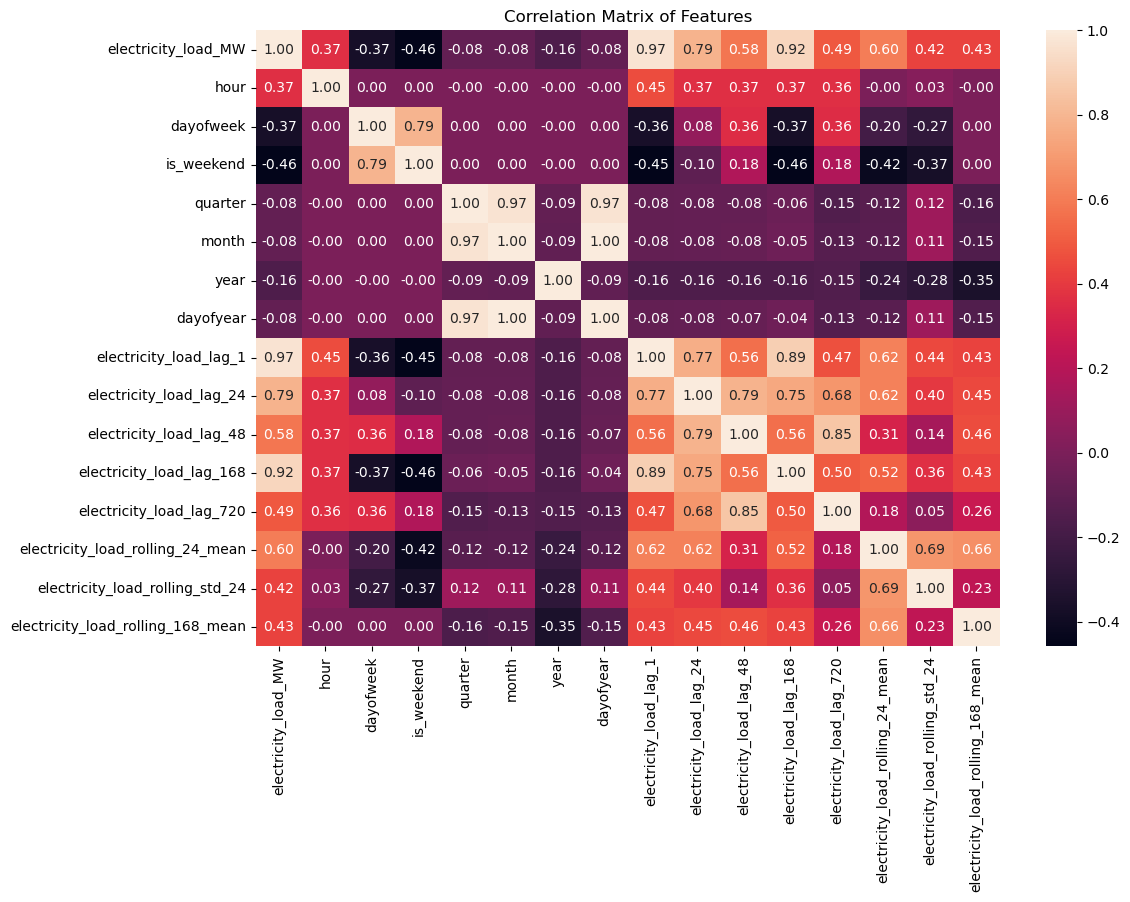

In [31]:
# Correlation Matrix, Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(germany_entso_df.corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()

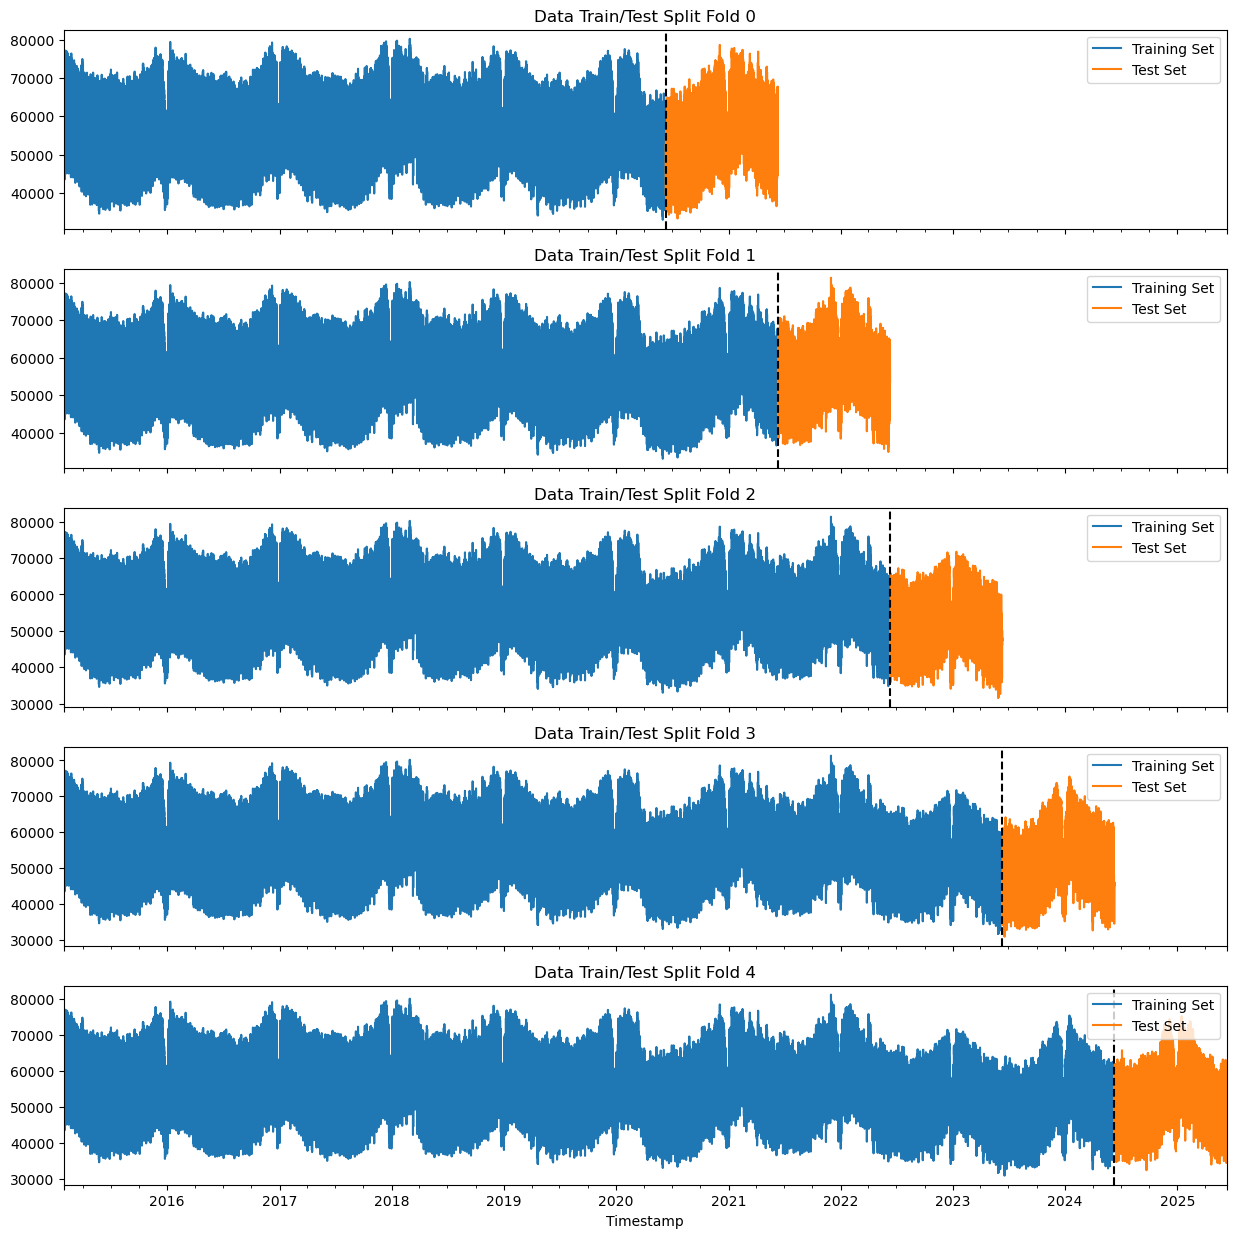

In [32]:
# Time Series Cross Validation Visualization 
tscv = TimeSeriesSplit(n_splits = 5, test_size = 24*365, gap = 24)
germany_entso_df = germany_entso_df.sort_index()


# Visualize Time Series Validation Split
fig, axs = plt.subplots(5, 1, figsize = (15, 15),
                             sharex =True)
fold = 0
for train_indx, val_indx in tscv.split(germany_entso_df):
    train = germany_entso_df.iloc[train_indx]
    test = germany_entso_df.iloc[val_indx]
    train["electricity_load_MW"].plot(label="Training Set", 
                                      title=f"Data Train/Test Split Fold {fold}", 
                                      ax=axs[fold])
    test["electricity_load_MW"].plot(label="Test Set", 
                                     ax=axs[fold])
    axs[fold].legend(["Training Set", "Test Set"], loc="upper right")
    axs[fold].axvline(test.index.min(), color="black", ls="--")
    fold += 1
plt.show()    

In [33]:
# Train Using Cross Validation

baseline_scores = []
xgb_scores = []

for train_indx, val_indx in tscv.split(germany_entso_df):
    train = germany_entso_df.iloc[train_indx]
    test = germany_entso_df.iloc[val_indx]
    

    Features = ["hour", "dayofweek", "is_weekend", "quarter", "month", "year", "dayofyear", "electricity_load_lag_1", 
                "electricity_load_lag_24", "electricity_load_lag_48", "electricity_load_lag_168", "electricity_load_lag_720",
                "electricity_load_rolling_24_mean", "electricity_load_rolling_std_24", "electricity_load_rolling_168_mean"]

    Target = "electricity_load_MW"

    X_train = train[Features]
    y_train = train[Target]
    X_test = test[Features]
    y_test = test[Target]
    
    model_xgb = XGBRegressor(
        n_estimators=1000,
        early_stopping_rounds=50,
        learning_rate=0.01,
        max_depth=6,
        random_state=42,
        objective="reg:squarederror"
    )

    model_xgb.fit(X_train, y_train, 
                  eval_set = [(X_train, y_train), (X_test, y_test)], 
                  verbose = 100)
    # Make Predictions
    y_pred_xgb = (model_xgb.predict(X_test)).astype(float)

    # Baseline
    baseline_pred = test["electricity_load_lag_168"]
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    baseline_scores.append(baseline_rmse)

    # Model evaluation xgb
    xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    xgb_scores.append(xgb_rmse)
    xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
    xgb_mape = mean_absolute_percentage_error(y_test, y_pred_xgb) * 100
    xgb_r2 = r2_score(y_test, y_pred_xgb)

[0]	validation_0-rmse:10015.11189	validation_1-rmse:9751.41533
[100]	validation_0-rmse:3864.93140	validation_1-rmse:3780.34267
[200]	validation_0-rmse:1675.81604	validation_1-rmse:1674.30770
[300]	validation_0-rmse:956.70369	validation_1-rmse:1016.51423
[400]	validation_0-rmse:741.10752	validation_1-rmse:834.63042
[500]	validation_0-rmse:658.25775	validation_1-rmse:767.26783
[600]	validation_0-rmse:605.47061	validation_1-rmse:722.33136
[700]	validation_0-rmse:575.56595	validation_1-rmse:698.84011
[800]	validation_0-rmse:555.63647	validation_1-rmse:682.73391
[900]	validation_0-rmse:539.07600	validation_1-rmse:669.37207
[999]	validation_0-rmse:526.64143	validation_1-rmse:660.11350
[0]	validation_0-rmse:9973.46012	validation_1-rmse:9562.22569
[100]	validation_0-rmse:3852.30223	validation_1-rmse:3690.97188
[200]	validation_0-rmse:1675.21306	validation_1-rmse:1613.71711
[300]	validation_0-rmse:961.46626	validation_1-rmse:954.94233
[400]	validation_0-rmse:746.63192	validation_1-rmse:769.3736

In [34]:
# Calculate the baseline mean square error for the model
print("Baseline RMSE:", np.mean(baseline_scores))
print("RMSE XGBoost:", np.mean(xgb_scores))

Baseline RMSE: 3900.286888948717
RMSE XGBoost: 680.3547303613342


The model beat the baseline by EUR 680! That's a good indicator that it will helpful in electricity load forecasting

In [35]:
# xgb Model evaluation
print("Model Y_xgb_Prediction:", y_pred_xgb)
print("RMSE XGBoost:", xgb_rmse)
print("MAE XGBoost:", xgb_mae)
print("MAPE XGBoost:", xgb_mape)
print("R2 XGBoost:", xgb_r2)

Model Y_xgb_Prediction: [44486.27734375 43783.5546875  41706.26171875 ... 42036.44140625
 44071.1015625  44014.92578125]
RMSE XGBoost: 714.131843660262
MAE XGBoost: 536.5858233447489
MAPE XGBoost: 1.0236104713217757
R2 XGBoost: 0.9937762831963162


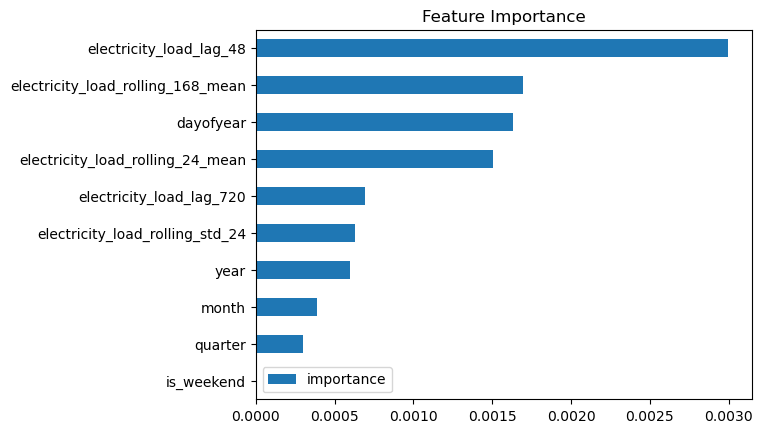

In [36]:
# Feature Importances

feature_import = pd.DataFrame(data=model_xgb.feature_importances_,
             index=model_xgb.feature_names_in_,
             columns=["importance"])

feature_import.sort_values("importance").head(10).plot(kind="barh", title="Feature Importance")
plt.show()

In [37]:
# Create a DataFrame df_predictions that has two columns: "Actual" and "Predicted"
df_predictions = pd.DataFrame(
    {
        "Actual": y_test,
        "Predicted": y_pred_xgb
    }
).round(2)

df_predictions

,Actual,Predicted
Timestamp,,
2024-06-09 21:00:00+02:00,44669.00,44486.28
2024-06-09 22:00:00+02:00,44615.50,43783.55
2024-06-09 23:00:00+02:00,41806.25,41706.26
2024-06-10 00:00:00+02:00,39539.75,39425.43
2024-06-10 01:00:00+02:00,38853.50,38113.92
...,...,...
2025-06-09 16:00:00+02:00,39745.00,39150.94
2025-06-09 17:00:00+02:00,41381.50,40702.14
2025-06-09 18:00:00+02:00,43501.00,42036.44


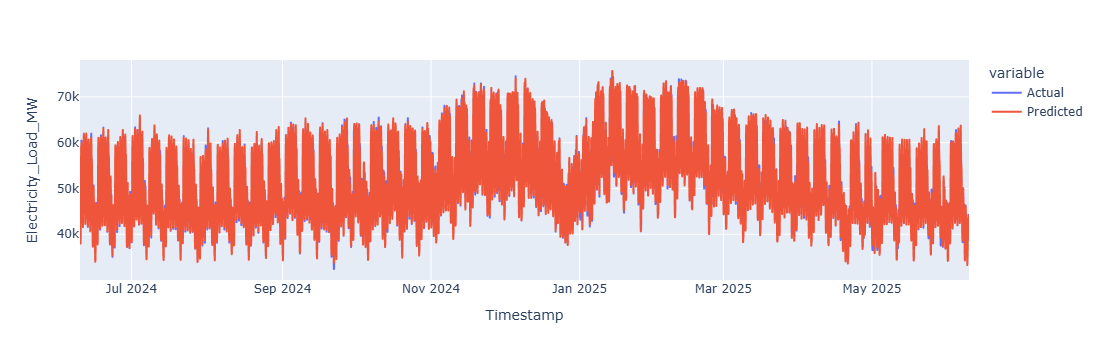

In [38]:
# Visualize a time series line plot for the values of predictions.

fig = px.line(df_predictions, labels={"value": "Electricity_Load_MW"})

fig.show()

In [39]:
# Interactive html plot

fig.write_html("forecast_electricity_load.html")

In [40]:
# Calculate Error

df_predictions["Error"] = df_predictions["Actual"] - df_predictions["Predicted"]
df_predictions

,Actual,Predicted,Error
Timestamp,,,
2024-06-09 21:00:00+02:00,44669.00,44486.28,182.72
2024-06-09 22:00:00+02:00,44615.50,43783.55,831.95
2024-06-09 23:00:00+02:00,41806.25,41706.26,99.99
2024-06-10 00:00:00+02:00,39539.75,39425.43,114.32
2024-06-10 01:00:00+02:00,38853.50,38113.92,739.58
...,...,...,...
2025-06-09 16:00:00+02:00,39745.00,39150.94,594.06
2025-06-09 17:00:00+02:00,41381.50,40702.14,679.36
2025-06-09 18:00:00+02:00,43501.00,42036.44,1464.56


In [41]:
# Save Model
joblib.dump(model_xgb, "electricity_xgb_model.joblib")

['electricity_xgb_model.joblib']

In [42]:
# Load Model 
loaded_model = joblib.load("electricity_xgb_model.joblib")

In [43]:
loaded_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)